# **Simulação de Epidemias**

## **código Auxiliar**

In [1]:
import networkx as nx
import random
import matplotlib.pyplot as plt
import numpy as np
import igraph as ig

In [2]:
def run_sis_simulation(G, beta, mu, initial_infected=5, t_max=300):
    """
    Executa uma simulação do modelo SIS em uma rede.

    Parâmetros:
    - G: O grafo (rede) NetworkX.
    - beta: Taxa de infecção por aresta.
    - mu: Taxa de recuperação.
    - initial_infected: Número de nós infectados iniciais.
    - t_max: Número máximo de passos de tempo.
    
    Retorna:
    - Uma lista com o número de infectados em cada passo de tempo.
    """
    
    N = G.number_of_nodes()
    
    # Dicionário para rastrear o estado de cada nó: 0=Suscetível, 1=Infectado
    state = {node: 0 for node in G.nodes()}
    
    # 1. Infectar os nós iniciais
    initial_nodes = random.sample(list(G.nodes()), initial_infected)
    for node in initial_nodes:
        state[node] = 1
        
    infected_history = []
    infected_count = initial_infected
    infected_history.append(infected_count)
    
    # 2. Loop da Simulação
    for t in range(t_max):
        
        # Se a epidemia morrer, pare cedo
        if infected_count == 0:
            infected_history.extend([0] * (t_max - t)) # Preenche o resto
            break
            
        # Dicionário para armazenar as mudanças de estado
        # Isso garante que todas as mudanças ocorram "simultaneamente"
        nodes_to_update = {}
        
        # Identifica os nós infectados atuais
        current_infected = [node for node, s in state.items() if s == 1]
        
        # 3. Processo de Infecção (S -> I)
        # Para ser eficiente, olhamos apenas para os vizinhos suscetíveis
        # dos nós já infectados.
        susceptible_neighbors_of_infected = set()
        for i in current_infected:
            for j in G.neighbors(i):
                if state[j] == 0: # Se o vizinho 'j' é suscetível
                    susceptible_neighbors_of_infected.add(j)
        
        for j in susceptible_neighbors_of_infected:
            # j é um nó suscetível com pelo menos um vizinho infectado
            
            # Contamos quantos vizinhos infectados 'j' tem
            k_i = 0
            for neighbor in G.neighbors(j):
                if state[neighbor] == 1:
                    k_i += 1
            
            # Probabilidade de ser infectado
            # P(inf) = 1 - P(não ser inf. por nenhum vizinho)
            prob_infection = 1 - (1 - beta)**k_i
            
            if random.random() < prob_infection:
                nodes_to_update[j] = 1 # Marcar para infecção
                
        # 4. Processo de Recuperação (I -> S)
        for i in current_infected:
            if random.random() < mu:
                # Mesmo que tenha sido marcado para infecção
                # (o que é impossível), a recuperação tem precedência
                # ou simplesmente não o infectamos.
                # Aqui, como 'i' já está infectado,
                # apenas checamos a recuperação.
                if i not in nodes_to_update: # Não foi recém-infectado
                    nodes_to_update[i] = 0 # Marcar para recuperação

        # 5. Aplicar todas as atualizações
        for node, new_state in nodes_to_update.items():
            state[node] = new_state
            
        # 6. Registrar contagem
        infected_count = sum(state.values())
        infected_history.append(infected_count)
        
    return infected_history


In [3]:
def run_sis_simulation_ig(G, beta, mu, initial_infected=5, t_max=300):
    """
    Executa uma simulação do modelo SIS em uma rede (grafo igraph).

    Parâmetros:
    - G: O grafo (rede) igraph.
    - beta: Taxa de infecção por aresta.
    - mu: Taxa de recuperação.
    - initial_infected: Número de nós infectados iniciais.
    - t_max: Número máximo de passos de tempo.
    
    Retorna:
    - Uma lista com o número de infectados em cada passo de tempo.
    """
    
    N = G.vcount() 
    
    # 2. Nós em igraph são índices de 0 a N-1
    # Usar range(N) em vez de G.nodes()
    state = {node: 0 for node in range(N)}
    
    # 3. Infectar os nós iniciais
    # Usar range(N) em vez de list(G.nodes())
    initial_nodes = random.sample(range(N), initial_infected)
    # --- FIM DAS MUDANÇAS ---
    
    for node in initial_nodes:
        state[node] = 1
        
    infected_history = []
    infected_count = initial_infected
    infected_history.append(infected_count)
    
    # 2. Loop da Simulação
    for t in range(t_max):
        
        # Se a epidemia morrer, pare cedo
        if infected_count == 0:
            infected_history.extend([0] * (t_max - t)) # Preenche o resto
            break
            
        # Dicionário para armazenar as mudanças de estado
        nodes_to_update = {}
        
        # Identifica os nós infectados atuais
        current_infected = [node for node, s in state.items() if s == 1]
        
        # 3. Processo de Infecção (S -> I)
        susceptible_neighbors_of_infected = set()
        for i in current_infected:
            # G.neighbors(i) funciona da mesma forma em igraph
            for j in G.neighbors(i):
                if state[j] == 0: # Se o vizinho 'j' é suscetível
                    susceptible_neighbors_of_infected.add(j)
        
        for j in susceptible_neighbors_of_infected:
            # j é um nó suscetível com pelo menos um vizinho infectado
            
            # Contamos quantos vizinhos infectados 'j' tem
            k_i = 0
            for neighbor in G.neighbors(j):
                if state[neighbor] == 1:
                    k_i += 1
            
            # Probabilidade de ser infectado
            prob_infection = 1 - (1 - beta)**k_i
            
            if random.random() < prob_infection:
                nodes_to_update[j] = 1 # Marcar para infecção
                
        # 4. Processo de Recuperação (I -> S)
        for i in current_infected:
            if random.random() < mu:
                if i not in nodes_to_update: # Não foi recém-infectado
                    nodes_to_update[i] = 0 # Marcar para recuperação

        # 5. Aplicar todas as atualizações
        for node, new_state in nodes_to_update.items():
            state[node] = new_state
            
        # 6. Registrar contagem
        infected_count = sum(state.values())
        infected_history.append(infected_count)
        
    return infected_history

In [4]:
def compute_proportion(X):
    """
    calcula a proporção de simulações que terminaram com 0 infectados em relação ao total de simulações

    X: list[list[int]], onde cada linha representa uma simulação

    return: proporção (float)
    """
    p = np.sum((X[:, -1] == 0).astype(np.uint8)) / X.shape[0]
    return p

In [5]:
def beautifull_hist(p, c1 = "#62AB5F", c2="#FE5F55", title="Proportion"):
    """
    Faz um plot de um histograma de duas barras bonito. Com uma das barras tendo tamanho p e a outra 1-p.

    p: float, proporção da primeira barra
    c1: string, cor da primeira barra (p)
    c2: string, cor da segunda barra (1-p)
    """
    fig, ax = plt.subplots(figsize=(12, 6)) #  Cria uma figura para a plotagem

    fig.patch.set_facecolor("#222222")  #  Faz o fundo da figura preto
    ax.set_facecolor("#222222")  #  Faz o fundo do plot preto

    text_color = 'white'  #  Cor para o texto do gráfico

    ax.bar(x=["Irradicado", "Endêmicos"], height=[p, 1-p], color=[c1, c2])
    ax.set_title(title, color=text_color)
    # ax.set_xlabel("Tempo", color=text_color)
    ax.set_ylabel("Proporção", color=text_color)

    ax.tick_params(colors=text_color)  # Cor dos valores nos eixos
    ax.spines['bottom'].set_color(text_color) # Cor dos eixos do gráfico
    ax.spines['top'].set_color(text_color)
    ax.spines['left'].set_color(text_color)
    ax.spines['right'].set_color(text_color)

    # plt.legend(facecolor="#222222", labelcolor=text_color, edgecolor="#222222")
    plt.tight_layout()

    plt.show()


In [6]:
def beautifull_plot(X, color = "#51CB20", title="plot", alpha=0.1):
    n_sim = len(X)
    t_max = len(X[0])
    fig, ax = plt.subplots(figsize=(12, 6)) #  Cria uma figura para a plotagem

    fig.patch.set_facecolor("#222222")  #  Faz o fundo da figura preto
    ax.set_facecolor("#222222")  #  Faz o fundo do plot preto

    avg_line = np.mean(X, axis=0)
    std_line = np.std(X, axis=0)

    ax.plot(avg_line, alpha=1, color=color, label="Mean")
    ax.fill_between(x=np.arange(t_max), y1=np.maximum(avg_line - std_line, np.zeros(t_max)), y2=avg_line + std_line, alpha=alpha, color=color, label="std")

    text_color = 'white'  #  Cor para o texto do gráfico

    ax.set_title(title, color=text_color)
    ax.set_xlabel("Tempo", color=text_color)
    ax.set_ylabel("Número de Infectados", color=text_color)

    ax.tick_params(colors=text_color)  # Cor dos valores nos eixos
    ax.spines['bottom'].set_color(text_color) # Cor dos eixos do gráfico
    ax.spines['top'].set_color(text_color)
    ax.spines['left'].set_color(text_color)
    ax.spines['right'].set_color(text_color)

    plt.legend(facecolor="#222222", labelcolor=text_color, edgecolor="#222222")
    plt.tight_layout()

    plt.show()    

In [10]:
batch_size = 10
color ="#FE5F55"
n_sim = 100
t_max_low = 300
t_max_high = 3000

## **1. Rede Aleatória**

In [8]:
N = 10000
avg_k = 20
p = avg_k / (N - 1) 

In [9]:
G_erdos = nx.erdos_renyi_graph(N, p, seed=42)

### **a) $\beta = 0.02$ e $\mu = 0.1$**

In [10]:
a_1_list = []
for i in range(n_sim):
    history = run_sis_simulation(G_erdos, beta=0.02, mu=0.1, initial_infected=5, t_max=t_max_low)
    a_1_list.append(history)
    if i % batch_size == 0: print(i / n_sim)
a_1_list = np.array(a_1_list)

0.0
0.1
0.2
0.3
0.4
0.5
0.6
0.7
0.8
0.9


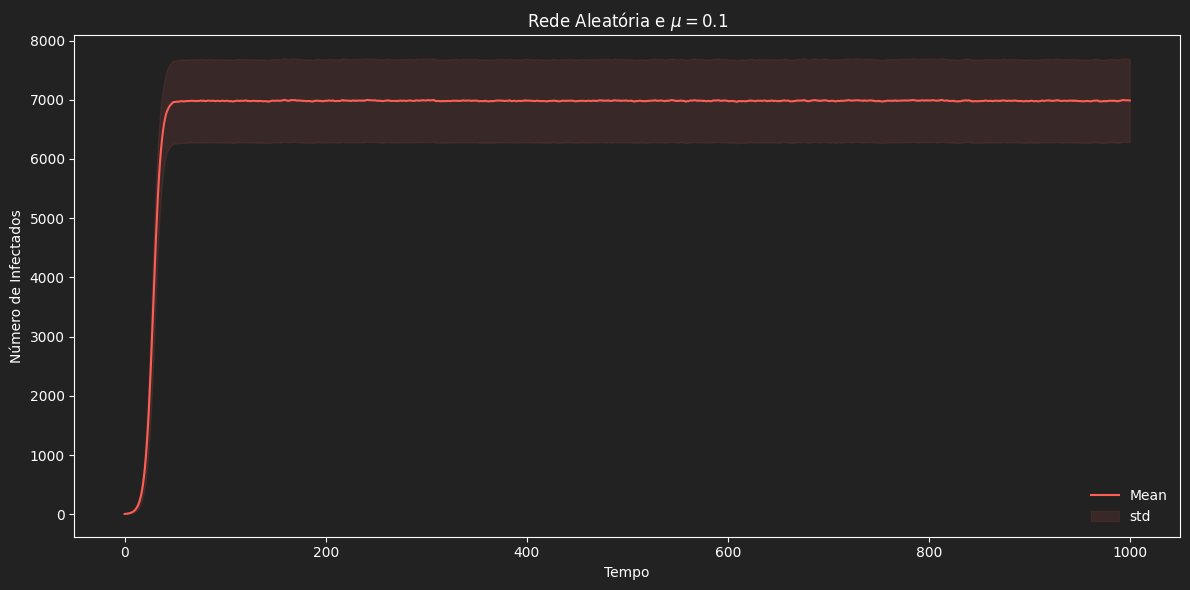

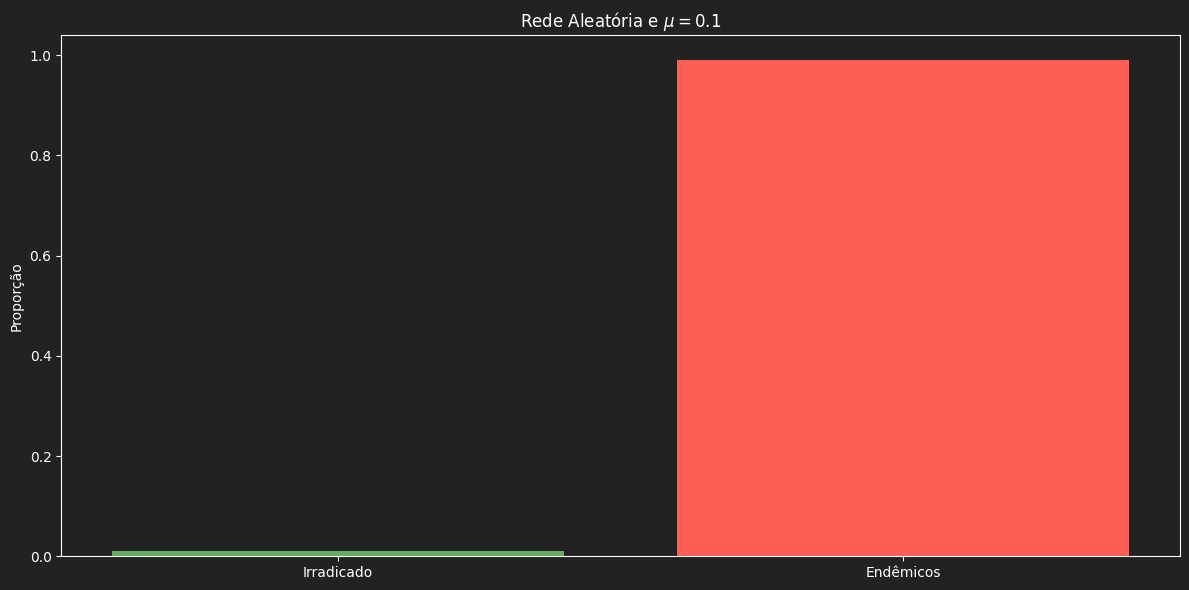

In [11]:
beautifull_plot(a_1_list, color=color, title="Rede Aleatória e $\mu = 0.1$")
beautifull_hist(compute_proportion(a_1_list),title="Rede Aleatória e $\mu = 0.1$")

### **b) $\beta = 0.02$ e $\mu = 0.4$**

In [12]:
b_1_list = []
n_sim=1000
for i in range(n_sim):
    history = run_sis_simulation(G_erdos, beta=0.02, mu=0.4, initial_infected=5, t_max=t_max_high)
    b_1_list.append(history)
    if i % batch_size == 0: print(i / n_sim)
b_1_list = np.array(b_1_list)

0.0
0.01
0.02
0.03
0.04
0.05
0.06
0.07
0.08
0.09
0.1
0.11
0.12
0.13
0.14
0.15
0.16
0.17
0.18
0.19
0.2
0.21
0.22
0.23
0.24
0.25
0.26
0.27
0.28
0.29
0.3
0.31
0.32
0.33
0.34
0.35
0.36
0.37
0.38
0.39
0.4
0.41
0.42
0.43
0.44
0.45
0.46
0.47
0.48
0.49
0.5
0.51
0.52
0.53
0.54
0.55
0.56
0.57
0.58
0.59
0.6
0.61
0.62
0.63
0.64
0.65
0.66
0.67
0.68
0.69
0.7
0.71
0.72
0.73
0.74
0.75
0.76
0.77
0.78
0.79
0.8
0.81
0.82
0.83
0.84
0.85
0.86
0.87
0.88
0.89
0.9
0.91
0.92
0.93
0.94
0.95
0.96
0.97
0.98
0.99


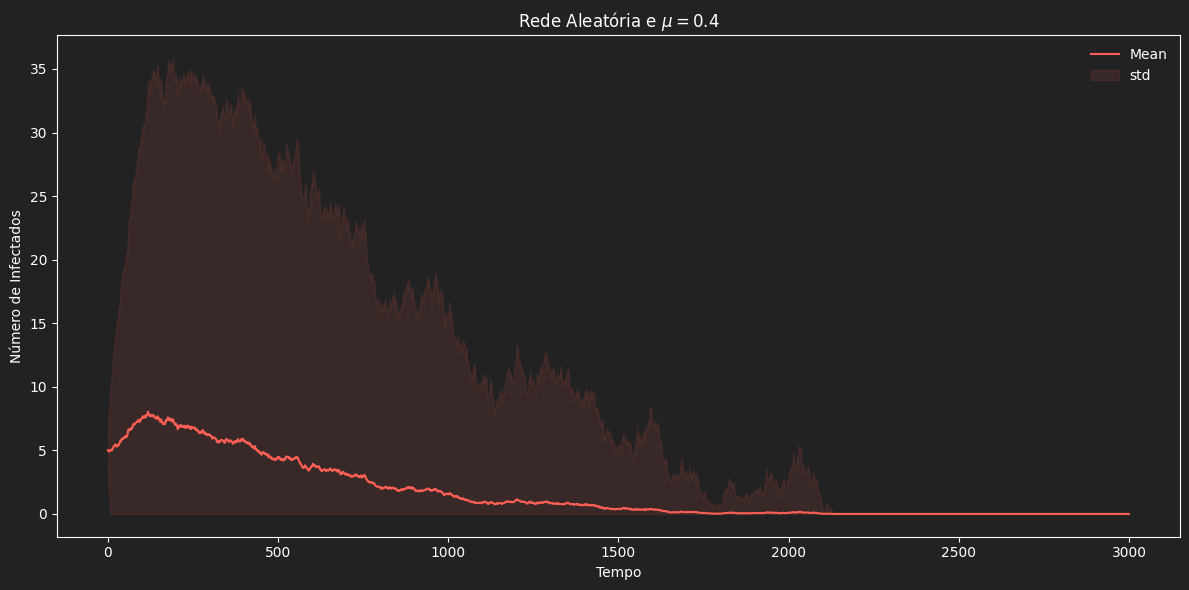

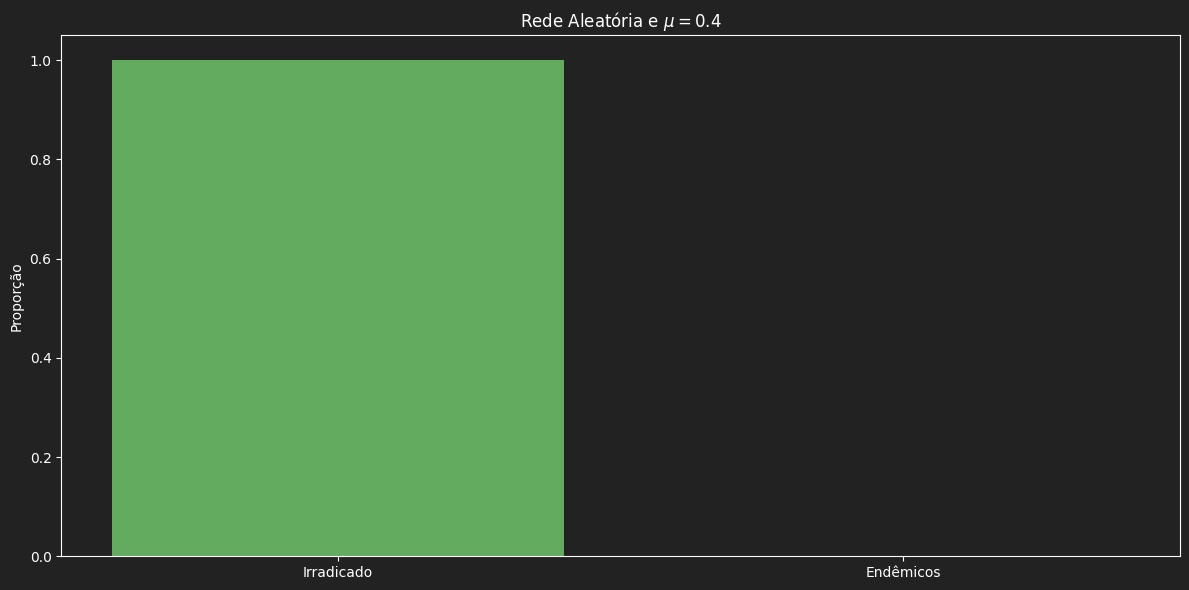

In [13]:
beautifull_plot(b_1_list, color=color, title="Rede Aleatória e $\mu = 0.4$")
beautifull_hist(compute_proportion(b_1_list),title="Rede Aleatória e $\mu = 0.4$")

### **c) $\beta = 0.02$ e $\mu = 0.5$**

In [14]:
c_1_list = []
for i in range(n_sim):
    history = run_sis_simulation(G_erdos, beta=0.02, mu=0.5, initial_infected=5, t_max=t_max_high)
    c_1_list.append(history)
    if i % batch_size == 0: print(i / n_sim)
c_1_list = np.array(c_1_list)

0.0
0.01
0.02
0.03
0.04
0.05
0.06
0.07
0.08
0.09
0.1
0.11
0.12
0.13
0.14
0.15
0.16
0.17
0.18
0.19
0.2
0.21
0.22
0.23
0.24
0.25
0.26
0.27
0.28
0.29
0.3
0.31
0.32
0.33
0.34
0.35
0.36
0.37
0.38
0.39
0.4
0.41
0.42
0.43
0.44
0.45
0.46
0.47
0.48
0.49
0.5
0.51
0.52
0.53
0.54
0.55
0.56
0.57
0.58
0.59
0.6
0.61
0.62
0.63
0.64
0.65
0.66
0.67
0.68
0.69
0.7
0.71
0.72
0.73
0.74
0.75
0.76
0.77
0.78
0.79
0.8
0.81
0.82
0.83
0.84
0.85
0.86
0.87
0.88
0.89
0.9
0.91
0.92
0.93
0.94
0.95
0.96
0.97
0.98
0.99


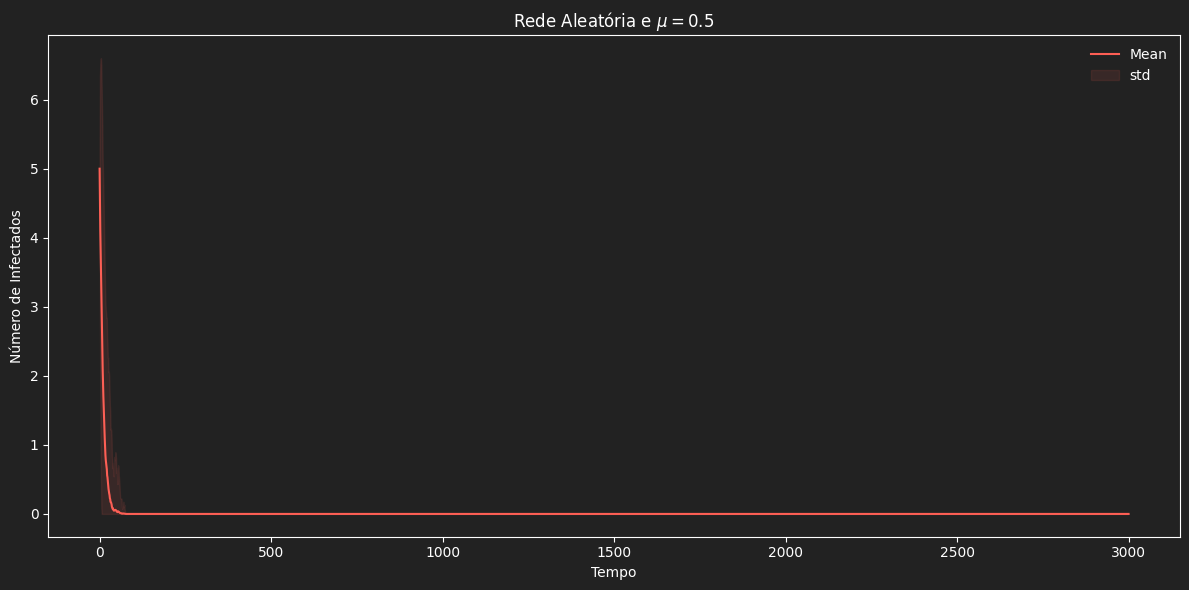

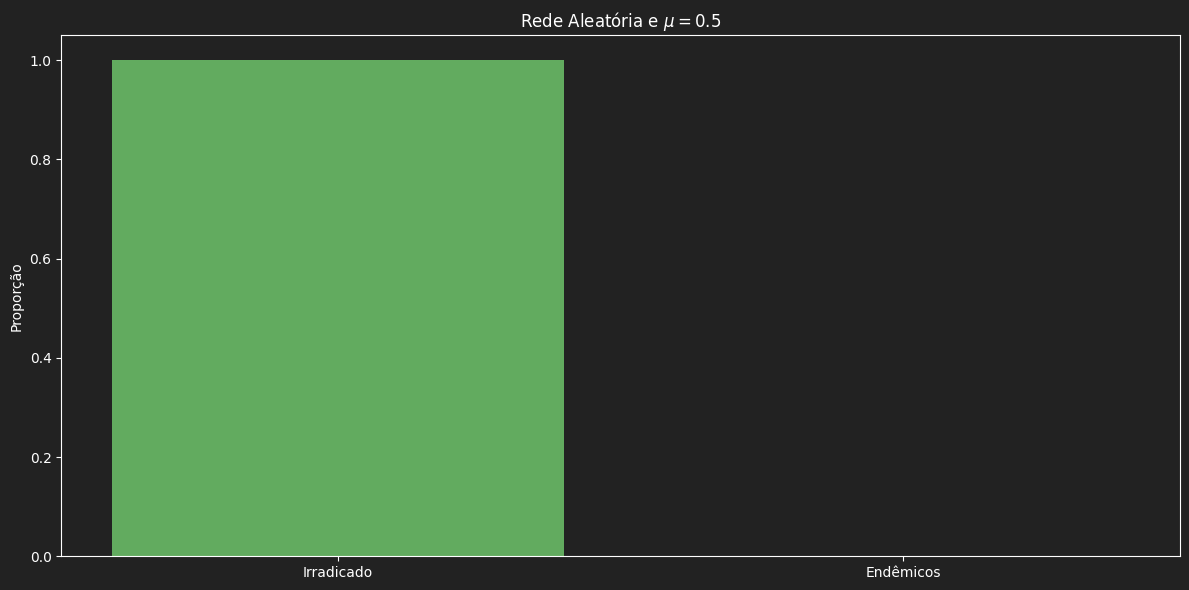

In [15]:
beautifull_plot(c_1_list, color=color, title="Rede Aleatória e $\mu = 0.5$")
beautifull_hist(compute_proportion(c_1_list),title="Rede Aleatória e $\mu = 0.5$")

## **2. Rede Livre de Escala**

In [9]:
num_nos = 10000
grau_medio = 20
gamma_expoente = 2.5

num_arestas = int((num_nos * grau_medio) / 2)

G_scale_free = ig.Graph.Static_Power_Law(
    n=num_nos,
    m=num_arestas,
    exponent_out=gamma_expoente,
    exponent_in=-1
)

### **a) $\beta = 0.01$ e $\mu = 0.1$**

In [17]:
a_2_list = []
for i in range(n_sim):
    history = run_sis_simulation_ig(G_scale_free, beta=0.01, mu=0.1, initial_infected=5, t_max=t_max_low)
    a_2_list.append(history)
    if i % batch_size == 0: print(i / n_sim)
a_2_list = np.array(a_2_list)

0.0
0.01
0.02
0.03
0.04
0.05
0.06
0.07
0.08
0.09
0.1
0.11
0.12
0.13
0.14
0.15
0.16
0.17
0.18
0.19
0.2
0.21
0.22
0.23
0.24
0.25
0.26
0.27
0.28
0.29
0.3
0.31
0.32
0.33
0.34
0.35
0.36
0.37
0.38
0.39
0.4
0.41
0.42
0.43
0.44
0.45
0.46
0.47
0.48
0.49
0.5
0.51
0.52
0.53
0.54
0.55
0.56
0.57
0.58
0.59
0.6
0.61
0.62
0.63
0.64
0.65
0.66
0.67
0.68
0.69
0.7
0.71
0.72
0.73
0.74
0.75
0.76
0.77
0.78
0.79
0.8
0.81
0.82
0.83
0.84
0.85
0.86
0.87
0.88
0.89
0.9
0.91
0.92
0.93
0.94
0.95
0.96
0.97
0.98
0.99


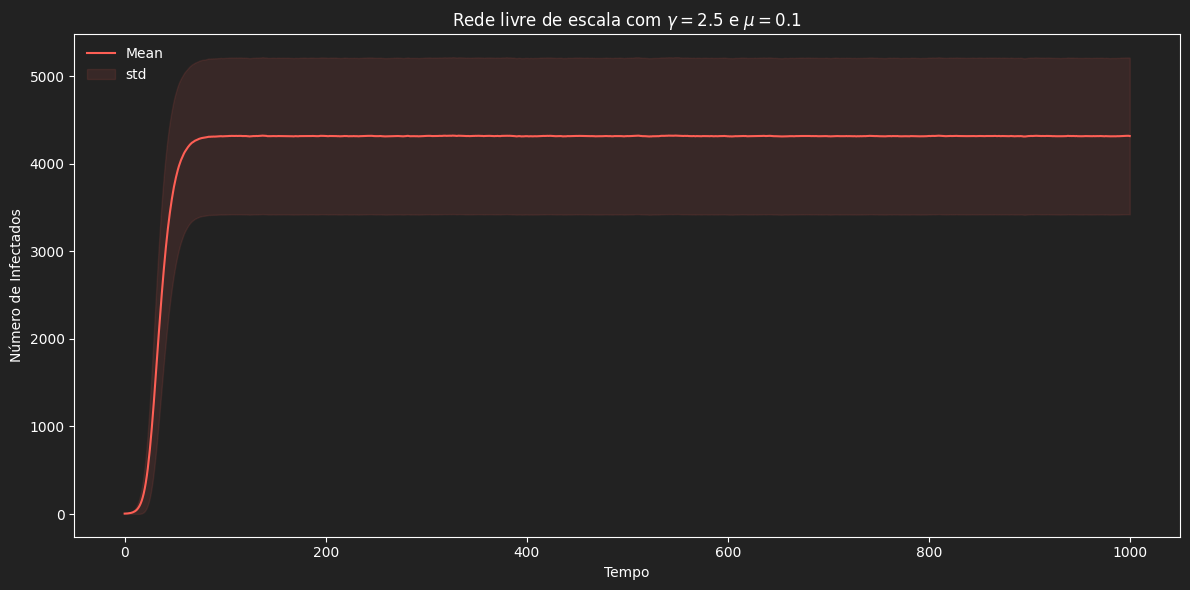

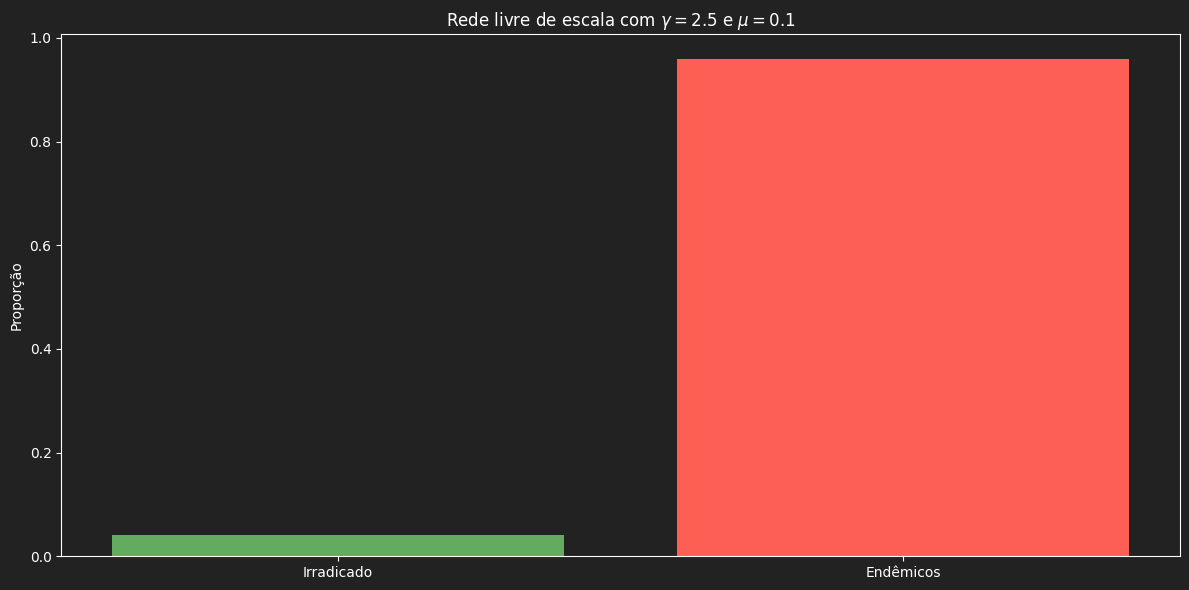

In [18]:
beautifull_plot(a_2_list, color=color, title="Rede livre de escala com $\gamma= 2.5$ e $\mu = 0.1$")
beautifull_hist(compute_proportion(a_2_list),title="Rede livre de escala com $\gamma= 2.5$ e $\mu = 0.1$")

### **b) $\beta = 0.01$ e $\mu = 0.2$**

In [12]:
b_2_list = []
for i in range(n_sim):
    history = run_sis_simulation_ig(G_scale_free, beta=0.01, mu=0.2, initial_infected=5, t_max=t_max_low)
    b_2_list.append(history)
    if i % batch_size == 0: print(i / n_sim)

b_2_list = np.array(b_2_list)

0.0
0.1
0.2
0.3
0.4
0.5
0.6
0.7
0.8
0.9


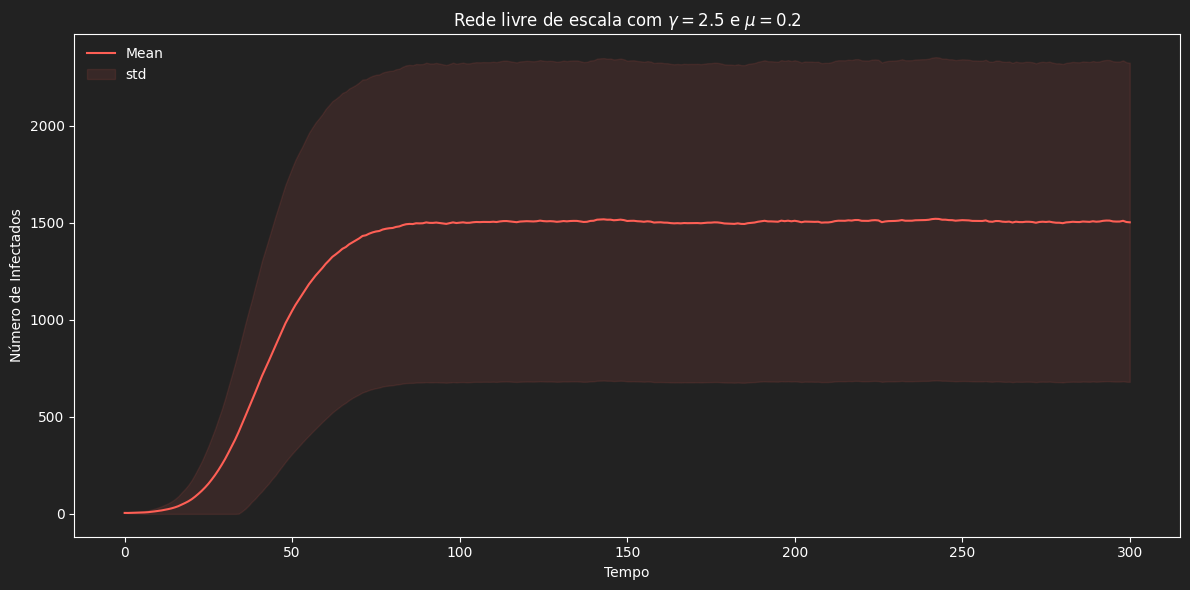

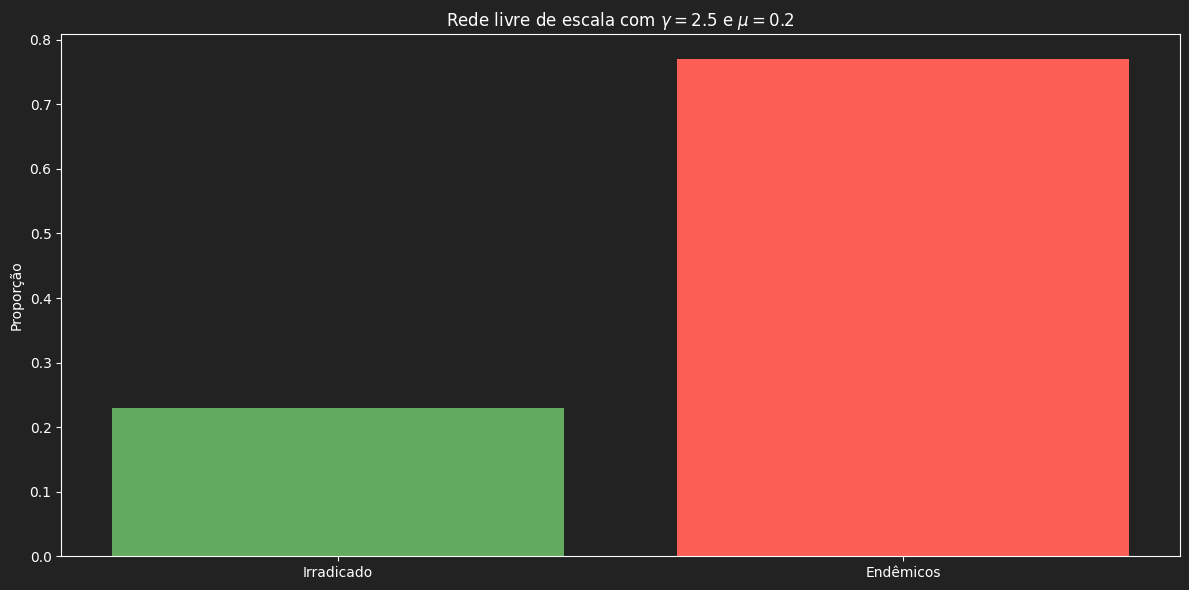

In [13]:
beautifull_plot(b_2_list, color=color, title="Rede livre de escala com $\gamma = 2.5$ e $\mu = 0.2$")
beautifull_hist(compute_proportion(b_2_list),title="Rede livre de escala com $\gamma= 2.5$ e $\mu = 0.2$")

### **c) $\beta = 0.01$ e $\mu = 0.3$**

In [ ]:
c_2_list = []
for i in range(n_sim):
    history = run_sis_simulation_ig(G_scale_free, beta=0.01, mu=0.3, initial_infected=5, t_max=300)
    c_2_list.append(history)
    if i % batch_size == 0: print(i / n_sim)

c_2_list = np.array(c_2_list)

0.0
0.01
0.02
0.03
0.04
0.05
0.06
0.07
0.08
0.09
0.1
0.11
0.12
0.13
0.14
0.15
0.16
0.17
0.18
0.19
0.2
0.21
0.22
0.23
0.24
0.25
0.26
0.27
0.28
0.29
0.3
0.31
0.32
0.33
0.34
0.35
0.36
0.37
0.38
0.39
0.4
0.41
0.42
0.43
0.44
0.45
0.46
0.47
0.48
0.49
0.5
0.51
0.52
0.53
0.54
0.55
0.56
0.57
0.58
0.59
0.6
0.61
0.62
0.63
0.64
0.65
0.66
0.67
0.68
0.69
0.7
0.71
0.72
0.73
0.74
0.75
0.76
0.77
0.78
0.79
0.8
0.81
0.82
0.83
0.84
0.85
0.86
0.87
0.88
0.89
0.9
0.91
0.92
0.93
0.94
0.95
0.96
0.97
0.98
0.99


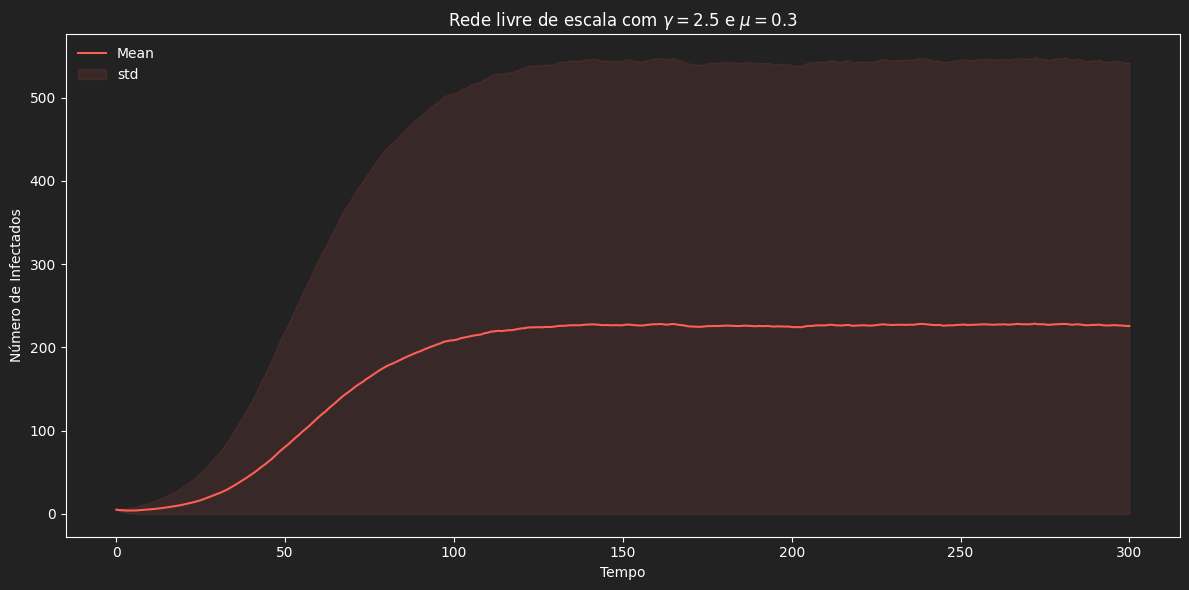

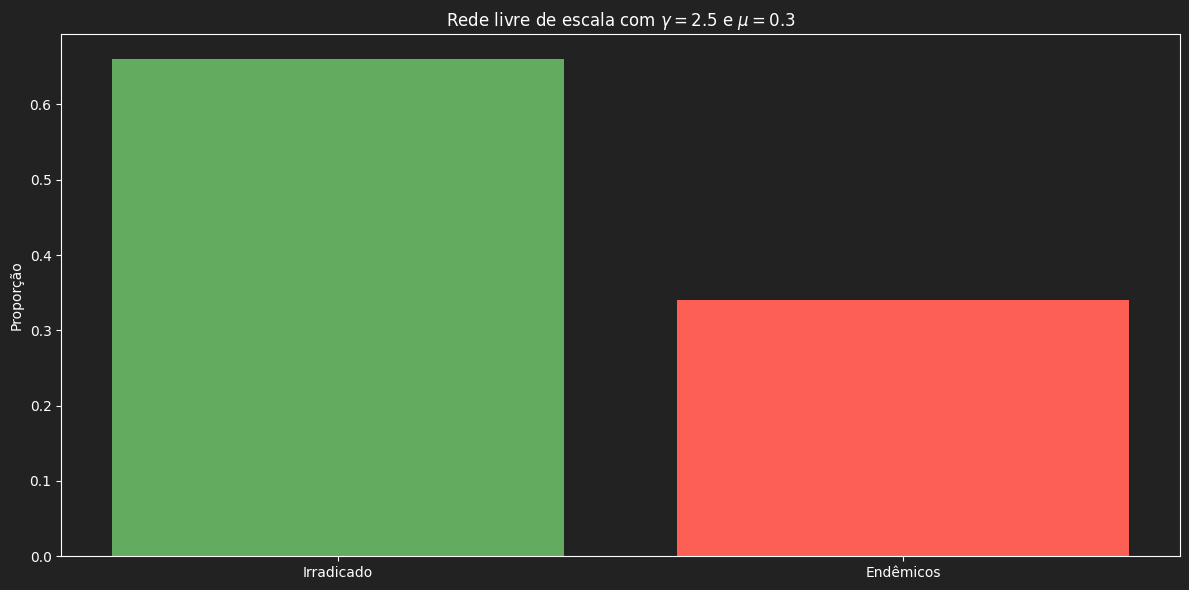

In [ ]:
beautifull_plot(c_2_list, color=color, title="Rede livre de escala com $\gamma= 2.5$ e $\mu = 0.3$")
beautifull_hist(compute_proportion(c_2_list),title="Rede livre de escala com $\gamma= 2.5$ e $\mu = 0.3$")